# Task 9 - K-Means Image Segmentation

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

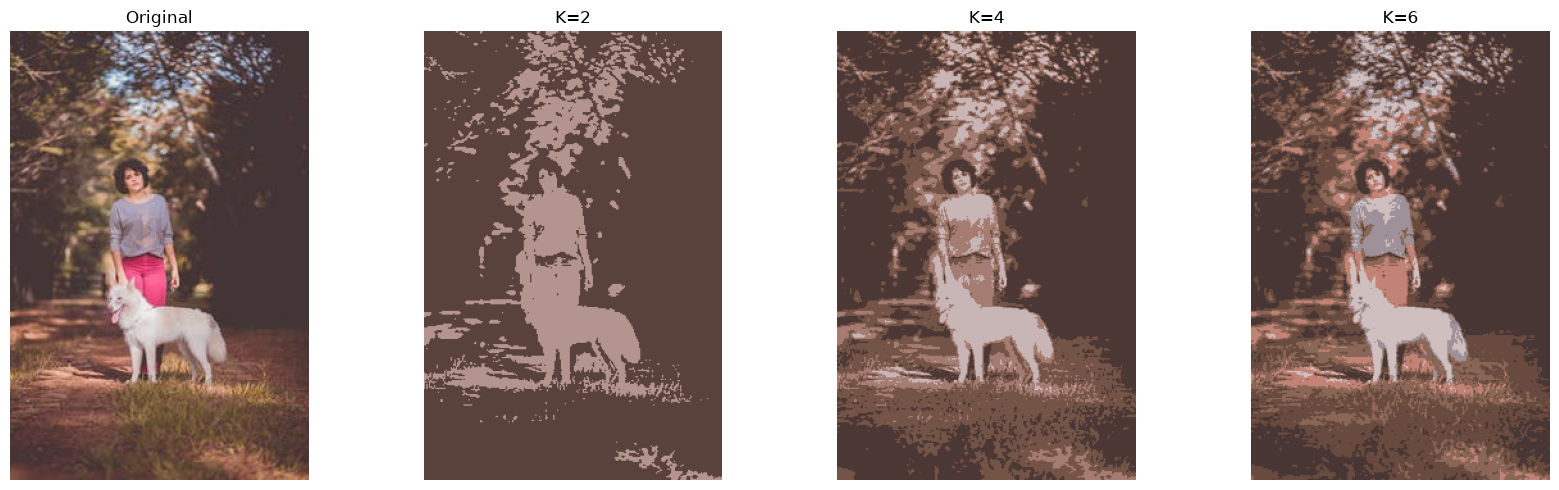

True

In [ ]:
bgr = cv2.imread("dog.jpeg")

if bgr is None:
    raise FileNotFoundError(
        "Place dog.jpeg in the notebook folder."
    )

# Convert the image from BGR to RGB for Matplotlib
rgb = cv2.cvtColor(
    bgr,
    cv2.COLOR_BGR2RGB
)

# Reshape the image into a list of RGB pixels
# Each row contains [R, G, B]
data = np.float32(
    rgb.reshape((-1, 3))
)


# ---------------------------------------------------------
# Define K-Means clustering criteria
# ---------------------------------------------------------

criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)


# ---------------------------------------------------------
# K-Means Image Segmentation Function
# ---------------------------------------------------------

def segment(K):
    """
    Segment the image using K-Means clustering.

    Parameters:
        K : Number of color clusters

    Returns:
        Segmented RGB image
    """

    # Set a fixed random seed for reproducible results
    cv2.setRNGSeed(42)

    # Apply K-Means clustering to the pixel colors
    _, labels, centers = cv2.kmeans(
        data,
        K,
        None,
        criteria,
        10,
        cv2.KMEANS_PP_CENTERS
    )

    # Convert cluster centers to 8-bit integers
    centers = np.uint8(centers)

    # Replace each pixel with the color of its cluster center
    segmented = centers[
        labels.flatten()
    ].reshape(rgb.shape)

    return segmented


# ---------------------------------------------------------
# Perform segmentation for different K values
# ---------------------------------------------------------

Ks = [2, 4, 6]

# Generate a segmented image for each K value
results = [
    segment(k)
    for k in Ks
]


# ---------------------------------------------------------
# Display the segmentation results
# ---------------------------------------------------------

fig, ax = plt.subplots(
    1,
    4,
    figsize=(17, 5)
)

# Display the original image
ax[0].imshow(rgb)
ax[0].set_title("Original")
ax[0].axis("off")

# Display the results for K = 2, 4, and 6
for a, k, image in zip(
    ax[1:],
    Ks,
    results
):
    a.imshow(image)
    a.set_title(f"K={k}")
    a.axis("off")

# Adjust spacing and display the results
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Save the K=6 segmentation result
# ---------------------------------------------------------

cv2.imwrite(
    str(OUT / "task9_final_k6.png"),
    cv2.cvtColor(
        results[-1],
        cv2.COLOR_RGB2BGR
    )
)


## Analysis
- `K=2`: strongest color simplification, only two representative color regions.
- `K=4`: preserves more major object/background color groups while remaining simplified.
- `K=6`: closest of these three to the original because more color centers are available.
The major regions represented by clusters are the dominant color populations of the animal, background and other scene components; exact semantic correspondence should be judged from the displayed image.